# 📊 Data Science Maaş Analizi — Keşifsel Veri Analizi (EDA)
**Kaynak:** [Kaggle — Data Science Job Salaries (ruchi798)](https://www.kaggle.com/datasets/ruchi798/data-science-job-salaries)  


## 🎯 Proje Amacı

Bu notebook, 2020–2022 yılları arasındaki veri bilimi pozisyonlarına ait maaş verilerini analiz etmektedir.  
Temel sorularımız:
1. **Deneyim seviyesi** maaşı nasıl etkiliyor?
2. **Yıllar içinde** ortalama maaşlar nasıl değişti?
3. **Şirket lokasyonu ve büyüklüğü** maaş üzerinde belirleyici mi?
4. **İş unvanı kategorisi** bazında maaş farklılıkları neler?

## 📁 Veri Seti Hakkında

| Kolon | Açıklama |
|---|---|
| `work_year` | Maaşın kaydedildiği yıl |
| `experience_level` | EN / MI / SE / EX (Junior → Executive) |
| `employment_type` | FT / PT / CT / FL |
| `job_title` | Pozisyon adı |
| `salary_in_usd` | USD cinsinden normalize edilmiş maaş |
| `employee_residence` | Çalışanın yaşadığı ülke |
| `remote_ratio` | Uzaktan çalışma oranı (0 / 50 / 100) |
| `company_location` | Şirketin ülkesi |
| `company_size` | S / M / L |

---

## 1. Kütüphaneler ve Genel Ayarlar

Projede kullanılan kütüphaneler:  
- **pandas / numpy**: Veri manipülasyonu  
- **matplotlib / seaborn / plotly**: Görselleştirme (statik + interaktif)  
- **sklearn.preprocessing**: Label encoding için (opsiyonel, burada elle yapıyoruz)  

> ⚙️ `sns.set_theme()` ile tüm grafiklerde tutarlı bir görünüm sağlıyoruz.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

# Plotly-interaktif grafikler için

try :
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False
    print("Plotly bulunamadı")
    
warnings.filterwarnings('ignore')
%matplotlib inline

# ── Global stil ayarları ──────────────────────────────────────────────────────
sns.set_theme(style='whitegrid',palette='muted',font_scale=1.1)
plt.rcParams.update({
    'figure.dpi' : 120,
    'axes.titlepad' : 14,
    'axes.labelpad' : 8
})

PALETTE = sns.color_palette('Blues_d', 4)   # Ana renk paleti
ACCENT  = '#E63946'                          # Vurgu rengi

print('✅ Kütüphaneler başarıyla yüklendi.')

✅ Kütüphaneler başarıyla yüklendi.


## 2. Veri Yükleme ve İlk İnceleme

Veriyi okuduktan sonra **shape**, **dtypes** ve **eksik değer** kontrolü yapıyoruz.  
Bu adım, ilerideki temizlik kararlarının temelini oluşturur.

In [2]:
df = pd.read_csv('ds_salaries.csv')

df.drop('Unnamed: 0', axis=1,inplace=True)

print(f"Boyut       : {df.shape[0]} satır x {df.shape[1]} ")
print(f"Eksik Değer : \n{df.isnull().sum().sum()} adet\n")
print(df.dtypes)

Boyut       : 607 satır x 11 
Eksik Değer : 
0 adet

work_year              int64
experience_level      object
employment_type       object
job_title             object
salary                 int64
salary_currency       object
salary_in_usd          int64
employee_residence    object
remote_ratio           int64
company_location      object
company_size          object
dtype: object


In [3]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


## 3. Keşifsel Görselleştirme (Ham Veri Üzerinde)

Herhangi bir encoding veya dönüşüm yapmadan önce dağılımları ve ilişkileri görselleştiriyoruz.  
Bu, veri hakkında sezgi geliştirmek ve encoding kararlarını doğrulamak açısından kritiktir.

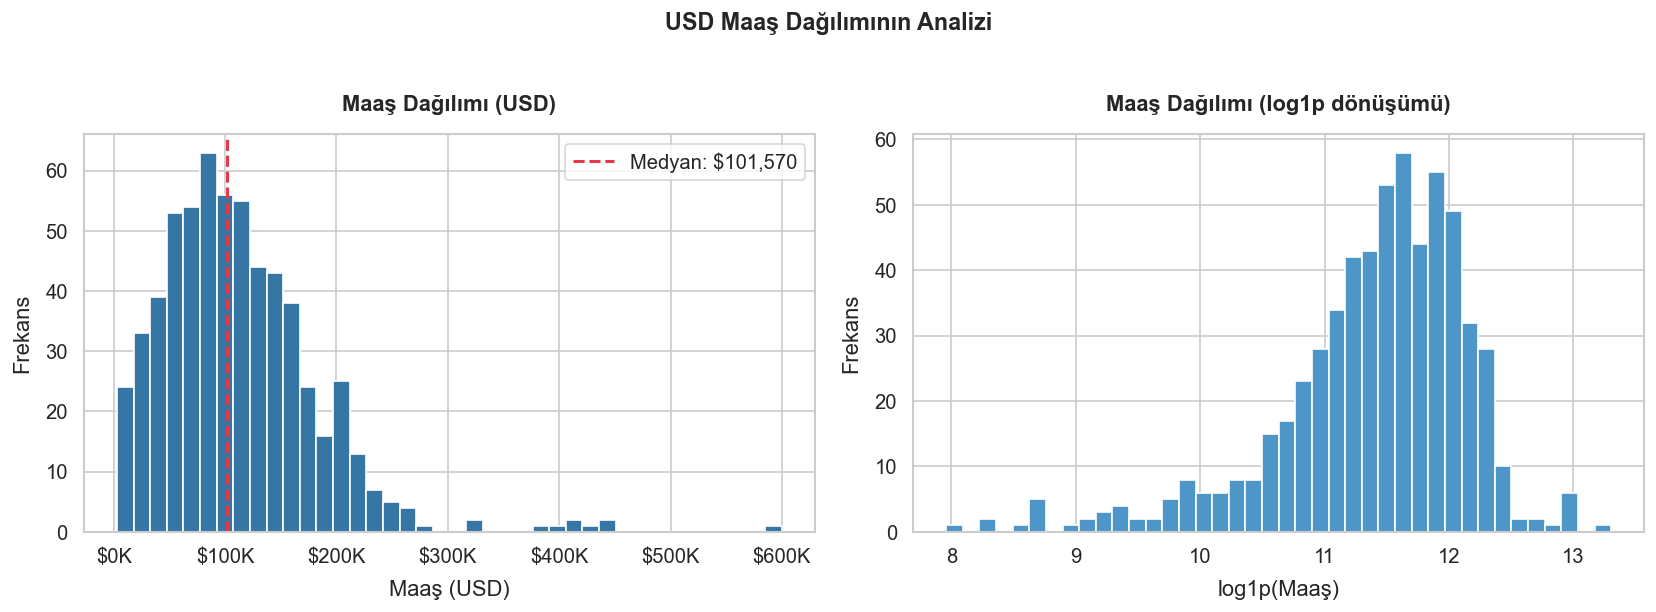

Çarpıklık (skewness): 1.668  →  sağa çarpık (pozitif)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol: Maaş dağılımı (histogram)
axes[0].hist(df['salary_in_usd'], bins=40, color=PALETTE[2], edgecolor='white')
axes[0].axvline(df['salary_in_usd'].median(), color=ACCENT, ls='--', lw=1.8, label=f"Medyan: ${df['salary_in_usd'].median():,.0f}")
axes[0].set_title('Maaş Dağılımı (USD)', fontweight='bold')
axes[0].set_xlabel('Maaş (USD)')
axes[0].set_ylabel('Frekans')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].legend()

# Sağ: Log-dönüşümlü dağılım (çarpıklığı görmek için)
axes[1].hist(np.log1p(df['salary_in_usd']), bins=40, color=PALETTE[1], edgecolor='white')
axes[1].set_title('Maaş Dağılımı (log1p dönüşümü)', fontweight='bold')
axes[1].set_xlabel('log1p(Maaş)')
axes[1].set_ylabel('Frekans')

plt.suptitle('USD Maaş Dağılımının Analizi', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

skew = df['salary_in_usd'].skew()
print(f'Çarpıklık (skewness): {skew:.3f}  →  {"sağa çarpık (pozitif)" if skew > 0 else "sola çarpık (negatif)"}')

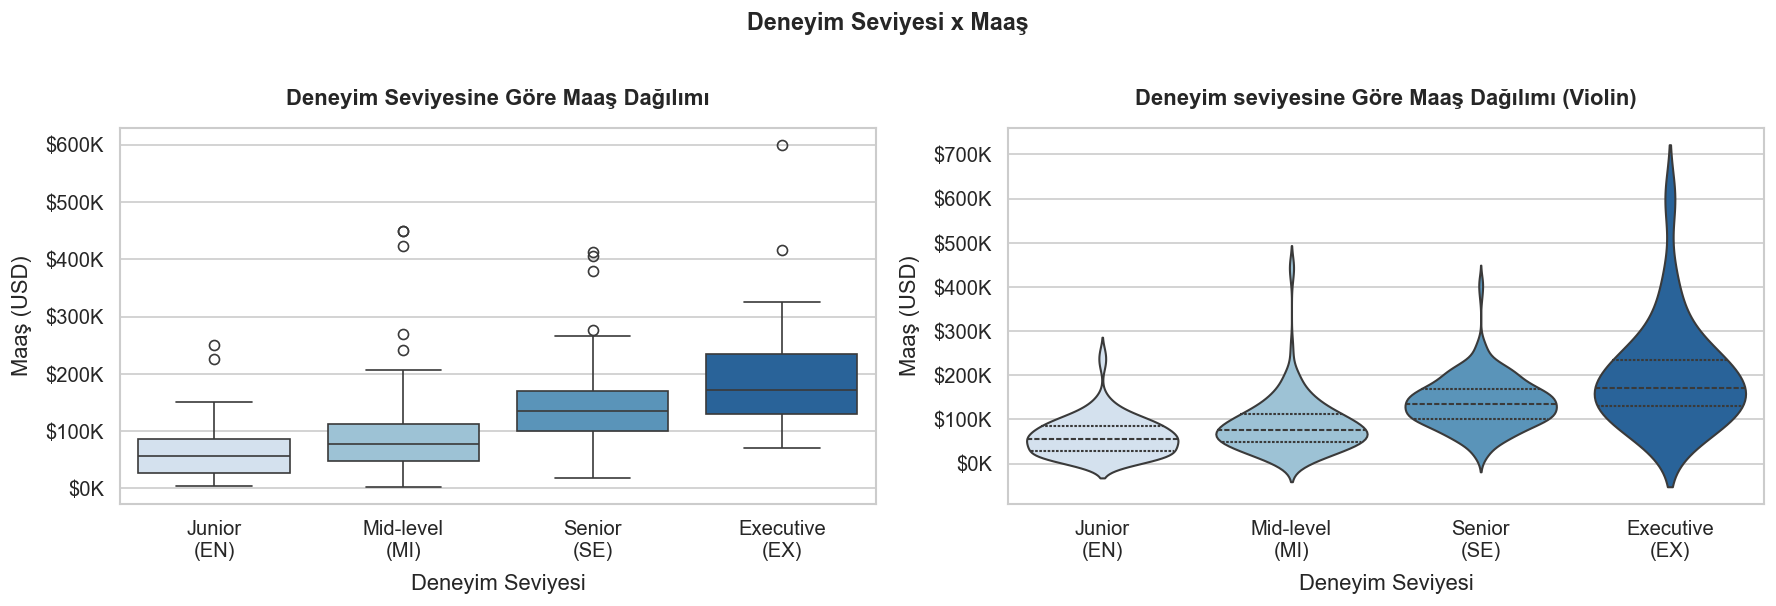

In [5]:
exp_order = ['EN','MI','SE','EX']
exp_labels = {'EN': 'Junior\n(EN)', 'MI': 'Mid-level\n(MI)', 'SE': 'Senior\n(SE)', 'EX': 'Executive\n(EX)'}

fig , axes = plt.subplots(1 , 2 , figsize=(15,5))

# Kutu grafiği
sns.boxplot(
    data = df, x = 'experience_level' , y = 'salary_in_usd',
    order = exp_order , palette= 'Blues' , ax = axes[0]
)
axes[0].set_title("Deneyim Seviyesine Göre Maaş Dağılımı", fontweight ='bold')
axes[0].set_xlabel("Deneyim Seviyesi")
axes[0].set_ylabel("Maaş (USD)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].set_xticklabels([exp_labels[e] for e in exp_order])

# Violin grafiği (dağılım şeklini daha iyi gösterir)
sns.violinplot(
    data=df , x = 'experience_level' , y = 'salary_in_usd',
    order = exp_order , palette='Blues' , inner='quartile', ax = axes[1]
)

axes[1].set_title("Deneyim seviyesine Göre Maaş Dağılımı (Violin)", fontweight = 'bold')
axes[1].set_xlabel('Deneyim Seviyesi')
axes[1].set_ylabel('Maaş (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[1].set_xticklabels([exp_labels[e] for e in exp_order])

plt.suptitle('Deneyim Seviyesi x Maaş', y = 1.01, fontsize = 14 , fontweight = 'bold')
plt.tight_layout()
plt.show()

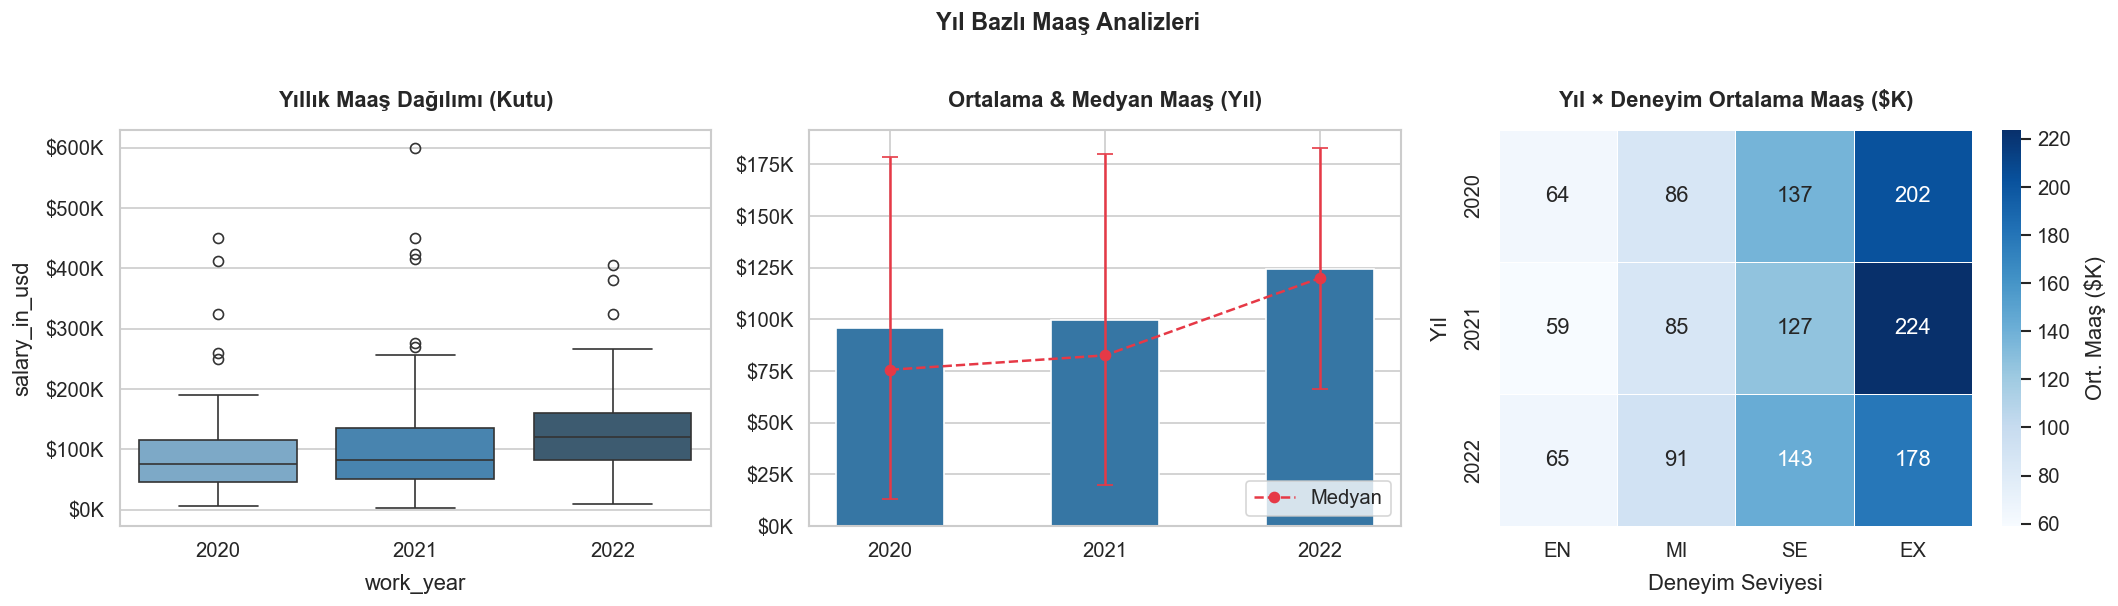

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Box plot
sns.boxplot(data=df, x='work_year', y='salary_in_usd', palette='Blues_d', ax=axes[0])
axes[0].set_title('Yıllık Maaş Dağılımı (Kutu)', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Bar plot — ortalama + hata çubuğu
year_stats = df.groupby('work_year')['salary_in_usd'].agg(['mean', 'median', 'std']).reset_index()
axes[1].bar(year_stats['work_year'].astype(str), year_stats['mean'],color=PALETTE[2], edgecolor='white', width=0.5)
axes[1].errorbar(range(len(year_stats)), year_stats['mean'], yerr=year_stats['std'],fmt='none', color=ACCENT, capsize=5, lw=1.5)
axes[1].plot(range(len(year_stats)), year_stats['median'],'o--', color=ACCENT, lw=1.5, label='Medyan')
axes[1].set_title('Ortalama & Medyan Maaş (Yıl)', fontweight='bold')
axes[1].set_xticks(range(len(year_stats)))
axes[1].set_xticklabels(year_stats['work_year'].astype(str))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[1].legend()

# Yıl × Deneyim heatmap (ortalama maaş)
pivot = df.groupby(['work_year', 'experience_level'])['salary_in_usd'].mean().unstack()
pivot = pivot.reindex(columns=exp_order)
sns.heatmap(pivot / 1000, annot=True, fmt='.0f', cmap='Blues',linewidths=0.5, ax=axes[2], cbar_kws={'label': 'Ort. Maaş ($K)'})
axes[2].set_title('Yıl × Deneyim Ortalama Maaş ($K)', fontweight='bold')
axes[2].set_xlabel('Deneyim Seviyesi')
axes[2].set_ylabel('Yıl')

plt.suptitle('Yıl Bazlı Maaş Analizleri', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

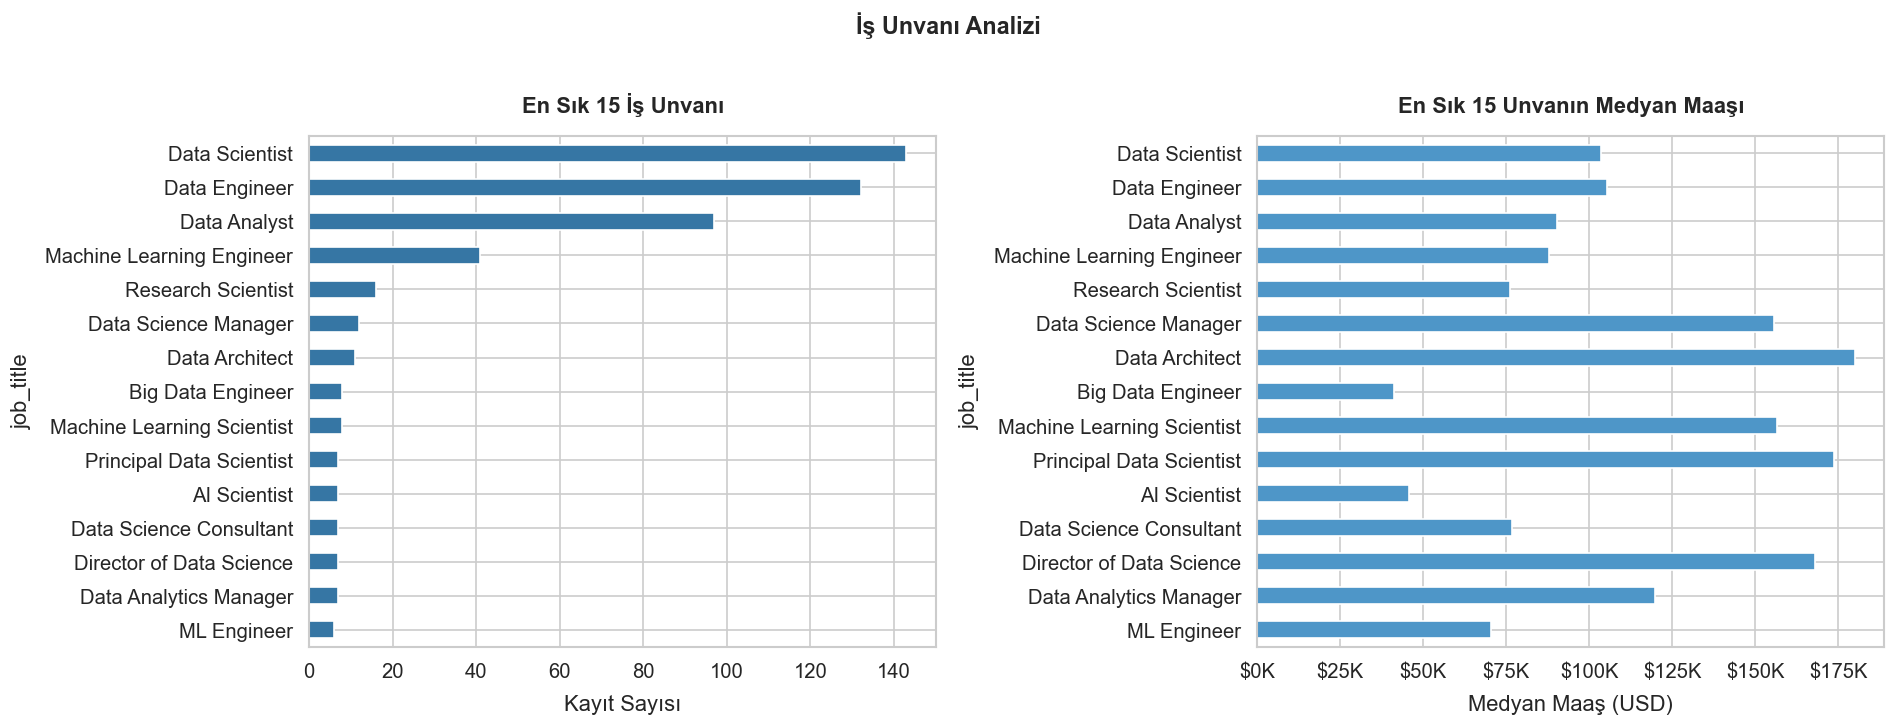

In [7]:
# En çok görünen 15 iş unvanı
top_titles = df['job_title'].value_counts().head(15)

fig,axes = plt.subplots(1,2,figsize=(16,6))

# Frekans
top_titles.plot(kind='barh',ax=axes[0],color = PALETTE[2],edgecolor='white')
axes[0].set_title("En Sık 15 İş Unvanı",fontweight = 'bold')
axes[0].set_xlabel('Kayıt Sayısı')
axes[0].invert_yaxis()

# Ortalama maaş (aynı unvanlar)
salary_by_title = (
    df[df['job_title'].isin(top_titles.index)]
    .groupby('job_title')['salary_in_usd']
    .median()
    .reindex(top_titles.index)
)
salary_by_title.plot(kind='barh', ax=axes[1], color=PALETTE[1], edgecolor='white')
axes[1].set_title('En Sık 15 Unvanın Medyan Maaşı', fontweight='bold')
axes[1].set_xlabel('Medyan Maaş (USD)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[1].invert_yaxis()

plt.suptitle('İş Unvanı Analizi', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

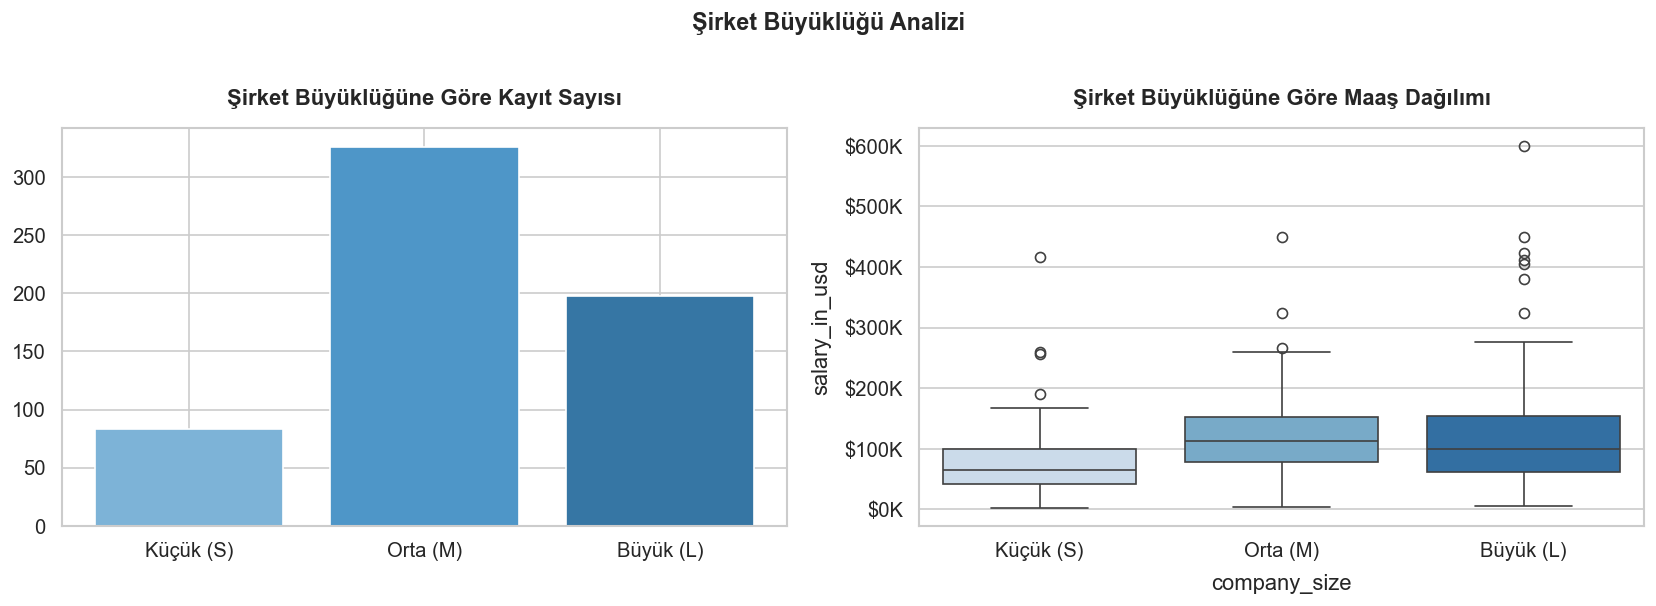

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Şirket büyüklüğü dağılımı
size_counts = df['company_size'].value_counts().reindex(['S', 'M', 'L'])
size_labels = ['Küçük (S)', 'Orta (M)', 'Büyük (L)']
axes[0].bar(size_labels, size_counts.values, color=PALETTE, edgecolor='white')
axes[0].set_title('Şirket Büyüklüğüne Göre Kayıt Sayısı', fontweight='bold')

# Şirket büyüklüğü × maaş
sns.boxplot(data=df, x='company_size', y='salary_in_usd',
            order=['S', 'M', 'L'], palette='Blues', ax=axes[1])
axes[1].set_title('Şirket Büyüklüğüne Göre Maaş Dağılımı', fontweight='bold')
axes[1].set_xticklabels(['Küçük (S)', 'Orta (M)', 'Büyük (L)'])
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.suptitle('Şirket Büyüklüğü Analizi', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Veri Ön İşleme (Feature Engineering)

Makine öğrenmesi modellerine hazırlık aşamasında:

1. **Sütun silme** — Model için anlamsız veya sızdırıcı (data-leaky) olan sütunlar kaldırılır.
2. **Ordinal encoding** — Doğal sıralaması olan kategorik değişkenler sayıya çevrilir (deneyim, şirket büyüklüğü, yıl).
3. **Bölge haritası** — Yüzlerce ülke kodunu 5 anlamlı bölgeye indirgemek, modelin genelleştirme kapasitesini artırır.
4. **İş unvanı kategorilendirme** — 50+ farklı unvanı 5 iş ailesine gruplamak, seyrek kategorileri ortadan kaldırır.
5. **One-Hot Encoding** — Nominal (sırasız) kategorik sütunlar ikili sütunlara dönüştürülür.

In [9]:
# ──Anlamsız / Sızdırıcı Sütunları Sil ────────────────────────────────────
# employment_type: neredeyse tamamı FT (tam zamanlı) → düşük varyans, kaldırıyoruz
# salary / salary_currency: salary_in_usd zaten normalleştirilmiş → gereksiz
# employee_residence: company_location ile yüksek korelasyon → çoklu doğrusallık riski

COLS_TO_DROP = ['employment_type', 'salary', 'salary_currency', 'employee_residence']
df.drop(columns=COLS_TO_DROP, inplace=True, errors='ignore')

print(f'Kalan sütunlar ({len(df.columns)}): {list(df.columns)}')

Kalan sütunlar (7): ['work_year', 'experience_level', 'job_title', 'salary_in_usd', 'remote_ratio', 'company_location', 'company_size']


In [10]:
# ──Ordinal Encoding ──────────────────────────────────────────────────────
# Sıralı kategoriler; sayısal büyüklük sıralamayı yansıtsın diye ordinal encoding kullanıyoruz.

EXPERIENCE_MAP   = {'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3}
COMPANY_SIZE_MAP = {'S': 0, 'M': 1, 'L': 2}
WORK_YEAR_MAP    = {2020: 0, 2021: 1, 2022: 2}

df['experience_level'] = df['experience_level'].map(EXPERIENCE_MAP)
df['company_size']     = df['company_size'].map(COMPANY_SIZE_MAP)
df['work_year']        = df['work_year'].map(WORK_YEAR_MAP)

In [11]:
# ── Şirket Lokasyonu → Coğrafi Bölge ─────────────────────────────────────
# 50+ ülke kodunu gruplamak overfitting'i azaltır ve modelin anlamlı kalıplar öğrenmesini sağlar.
# Bilinmeyen ülke kodları 'Diger' olarak atanır (fallback).

REGION_MAP = {
    # Kuzey/Güney/Orta Amerika
    'US': 'Amerika', 'CA': 'Amerika', 'MX': 'Amerika',
    'BR': 'Amerika', 'CO': 'Amerika', 'CL': 'Amerika', 'HN': 'Amerika',
    # Avrupa (Türkiye ve Rusya dahil)
    'GB': 'Avrupa', 'DE': 'Avrupa', 'FR': 'Avrupa', 'ES': 'Avrupa',
    'GR': 'Avrupa', 'NL': 'Avrupa', 'AT': 'Avrupa', 'PT': 'Avrupa',
    'PL': 'Avrupa', 'LU': 'Avrupa', 'TR': 'Avrupa', 'DK': 'Avrupa',
    'IT': 'Avrupa', 'CZ': 'Avrupa', 'SI': 'Avrupa', 'RU': 'Avrupa',
    'CH': 'Avrupa', 'BE': 'Avrupa', 'EE': 'Avrupa', 'MD': 'Avrupa',
    'MT': 'Avrupa', 'UA': 'Avrupa', 'RO': 'Avrupa', 'HR': 'Avrupa',
    'HU': 'Avrupa', 'IE': 'Avrupa',
    # Asya (Orta Doğu dahil)
    'IN': 'Asya', 'JP': 'Asya', 'PK': 'Asya', 'AE': 'Asya',
    'CN': 'Asya', 'VN': 'Asya', 'MY': 'Asya', 'SG': 'Asya',
    'IR': 'Asya', 'IL': 'Asya', 'IQ': 'Asya',
    # Afrika
    'NG': 'Afrika', 'DZ': 'Afrika', 'KE': 'Afrika',
    # Okyanusya / Diğer
    'AU': 'Diger', 'NZ': 'Diger', 'AS': 'Diger',
}

df['company_location'] = df['company_location'].map(REGION_MAP).fillna('Diger')

print('Bölge dağılımı:')
print(df['company_location'].value_counts().to_string())

Bölge dağılımı:
company_location
Amerika    394
Avrupa     160
Asya        44
Diger        5
Afrika       4


In [12]:
# ──İş Unvanı Kategorilendirme ───────────────────────────────────────────
# 50+ benzersiz unvanı 5 geniş kategoriye indirgemek:
#   a) Seyrek sınıfları (örn. 1-2 örnekli unvanlar) ortadan kaldırır.
#   b) Modelin anlamlı bir iş ailesi öğrenmesini sağlar.
# Öncelik sırası önemlidir: 'ML Engineer' hem ML hem engineer içerir → ML önce gelir.

TITLE_KEYWORDS = {
    'Machine Learning': ['machine learning', 'ml', 'computer vision', 'nlp','natural language', 'deep learning', 'ai'],
    'Data Scientist':   ['scientist'],
    'Data Engineer':    ['engineer', 'architect', 'etl', 'pipeline'],
    'Data Analyst':     ['analyst', 'analytics', 'bi', 'business intelligence'],
}
DEFAULT_CATEGORY = 'Data Manager / Other'

def classify_job_title(title: str) -> str:
    """İş unvanını anahtar kelimelere göre geniş bir kategoriye atar."""
    title_lower = str(title).lower()
    for category, keywords in TITLE_KEYWORDS.items():
        if any(kw in title_lower for kw in keywords):
            return category
    return DEFAULT_CATEGORY

df['job_category'] = df['job_title'].apply(classify_job_title)
df.drop(columns=['job_title'], inplace=True)

print('Kategori dağılımı:')
print(df['job_category'].value_counts().to_string())

Kategori dağılımı:
job_category
Data Engineer           183
Data Scientist          175
Data Analyst            127
Machine Learning         86
Data Manager / Other     36


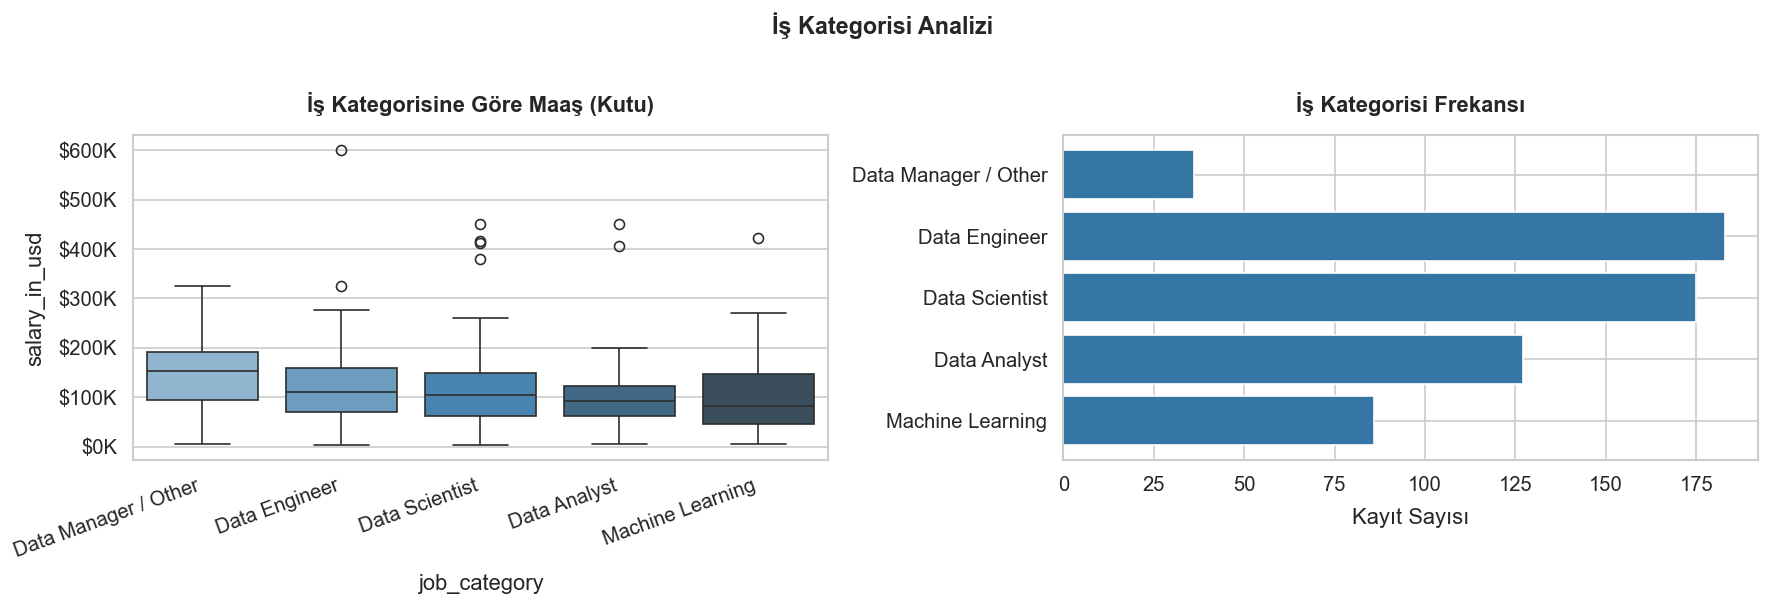

In [13]:
# İş kategorisi × maaş karşılaştırması
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cat_order = df.groupby('job_category')['salary_in_usd'].median().sort_values(ascending=False).index

sns.boxplot(data=df, x='job_category', y='salary_in_usd', order=cat_order,
            palette='Blues_d', ax=axes[0])
axes[0].set_title('İş Kategorisine Göre Maaş (Kutu)', fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha='right')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

cat_counts = df['job_category'].value_counts().reindex(cat_order)
axes[1].barh(cat_counts.index, cat_counts.values, color=PALETTE[2], edgecolor='white')
axes[1].set_title('İş Kategorisi Frekansı', fontweight='bold')
axes[1].set_xlabel('Kayıt Sayısı')
axes[1].invert_yaxis()

plt.suptitle('İş Kategorisi Analizi', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# ──One-Hot Encoding ──────────────────────────────────────────────────────
# Nominal (sırasız) kategoriler için OHE kullanıyoruz.
# drop_first=True → dummy değişken tuzağını (multicollinearity) önler.
# dtype=int → boolean yerine 0/1 tamsayı; çoğu ML kütüphanesiyle uyumlu.

NOMINAL_COLS = ['company_location', 'job_category']
df = pd.get_dummies(df, columns=NOMINAL_COLS, drop_first=True, dtype=int)

print(f'OHE sonrası boyut: {df.shape}')
df.head()

OHE sonrası boyut: (607, 13)


,work_year,experience_level,salary_in_usd,remote_ratio,company_size,company_location_Amerika,company_location_Asya,company_location_Avrupa,company_location_Diger,job_category_Data Engineer,job_category_Data Manager / Other,job_category_Data Scientist,job_category_Machine Learning
0,0,1,79833,0,2,0,0,1,0,0,0,1,0
1,0,2,260000,0,0,0,1,0,0,0,0,0,1
2,0,2,109024,50,1,0,0,1,0,1,0,0,0
3,0,1,20000,0,0,1,0,0,0,0,0,0,0
4,0,2,150000,50,2,1,0,0,0,0,0,0,1


---
## 5. Son Veri Seti — Korelasyon ve Dağılım Analizi

Encoding sonrasında ;korelasyon matrisi ile özellikler arasındaki ilişkileri inceliyoruz.  
Yüksek korelasyonlu çift özellikler, model eğitiminde çıkarılabilir.

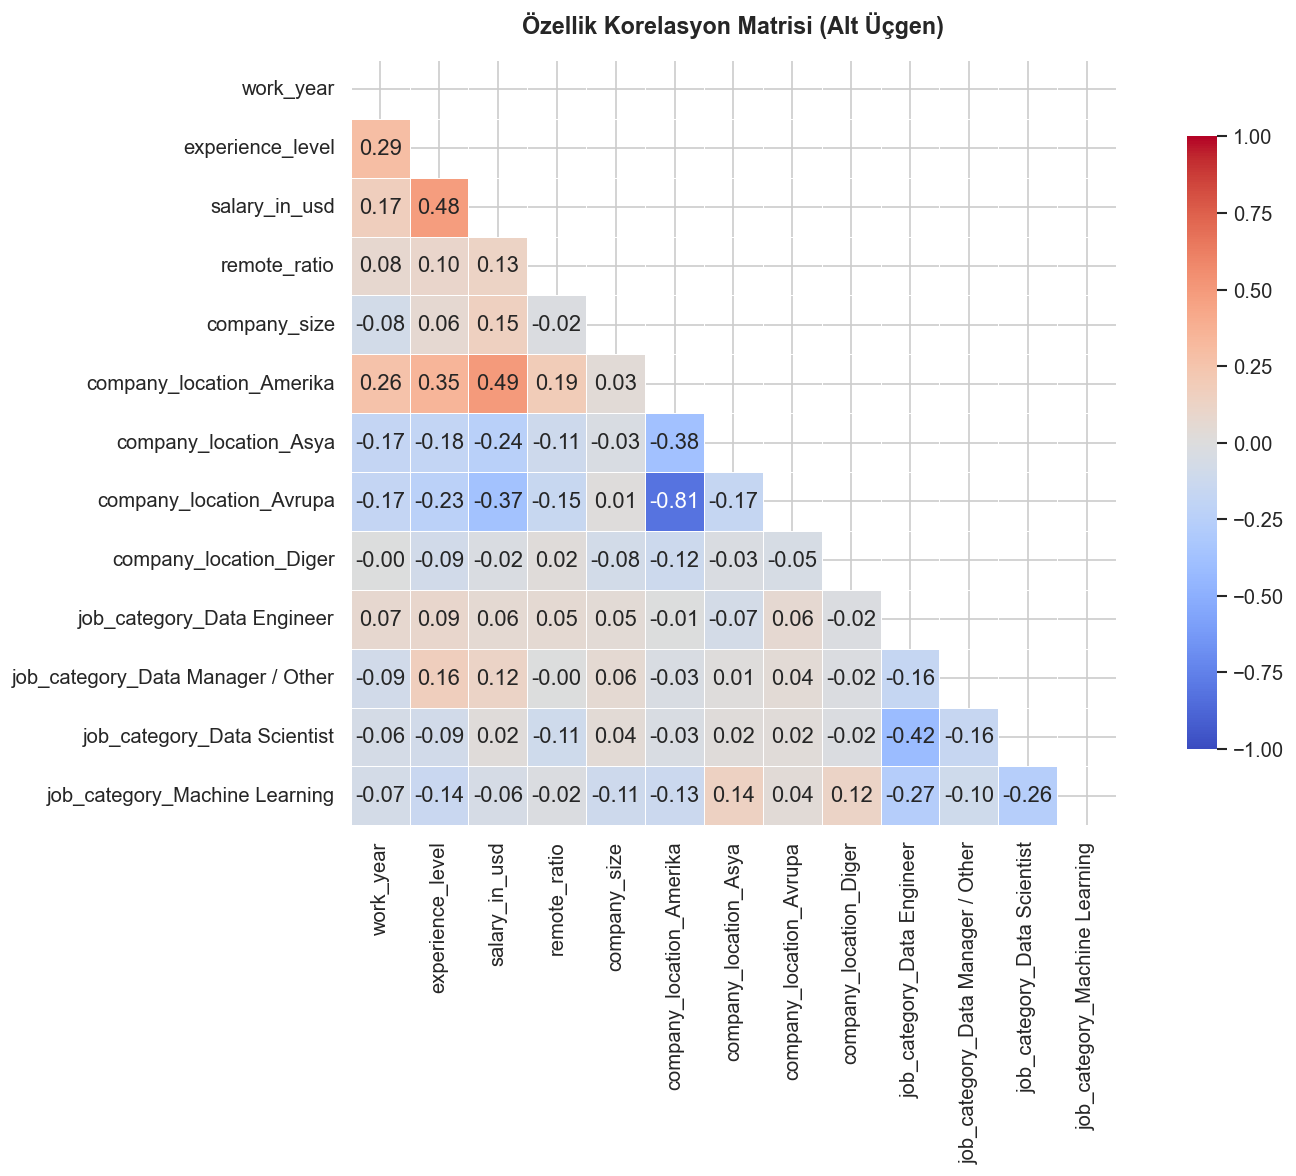


Hedef değişken (salary_in_usd) ile korelasyon (mutlak değer, büyükten küçüğe):
company_location_Amerika             0.492872
experience_level                     0.484233
company_location_Avrupa             -0.370141
company_location_Asya               -0.244711
work_year                            0.170493
company_size                         0.151205
remote_ratio                         0.132122
job_category_Data Manager / Other    0.124089
job_category_Machine Learning       -0.058903
job_category_Data Engineer           0.055702
company_location_Diger              -0.024245
job_category_Data Scientist          0.020447


In [15]:
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Üst üçgeni gizle (simetrik)
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.4, square=True, cbar_kws={'shrink': 0.8},
    ax=ax
)
ax.set_title('Özellik Korelasyon Matrisi (Alt Üçgen)', fontsize=14, fontweight='bold', pad=16)
plt.tight_layout()
plt.show()

# salary_in_usd ile en güçlü korelasyonlar
target_corr = corr['salary_in_usd'].drop('salary_in_usd').sort_values(key=abs, ascending=False)
print('\nHedef değişken (salary_in_usd) ile korelasyon (mutlak değer, büyükten küçüğe):')
print(target_corr.to_string())

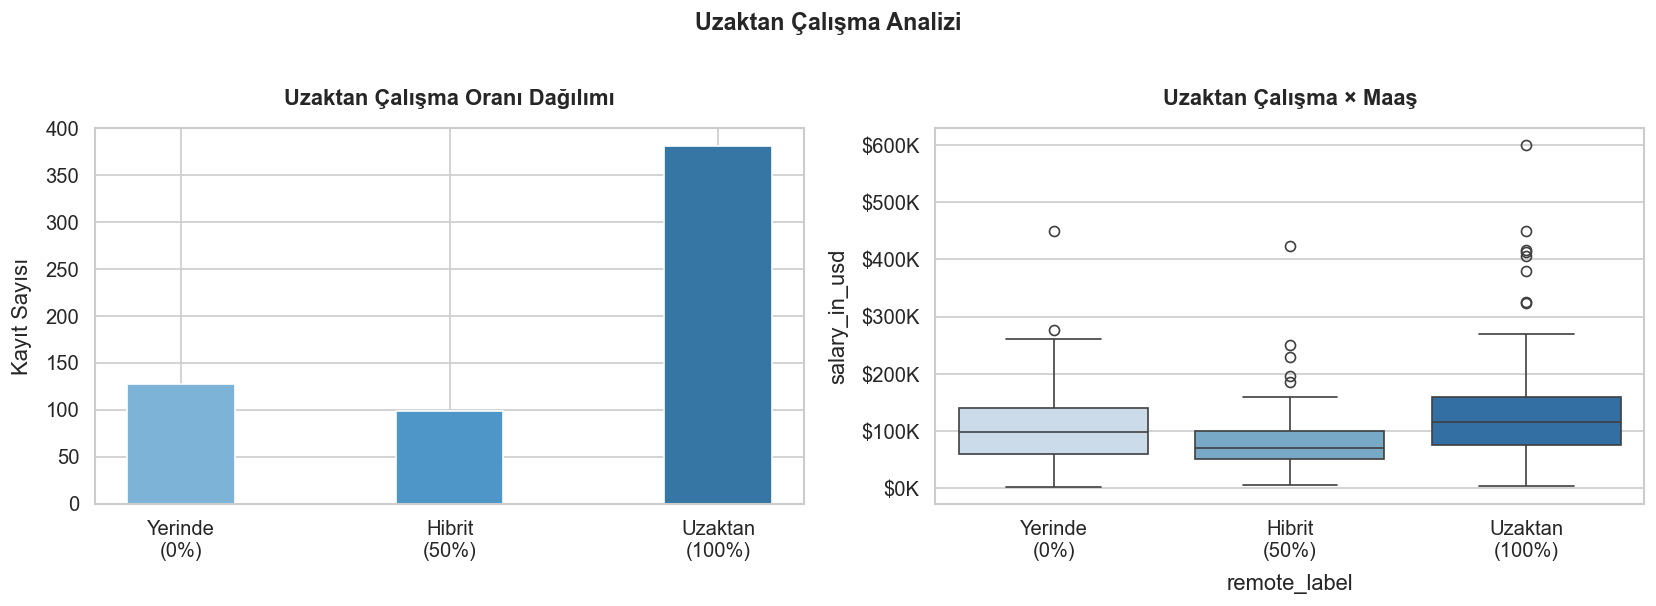

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

remote_labels = {0: 'Yerinde\n(0%)', 50: 'Hibrit\n(50%)', 100: 'Uzaktan\n(100%)'}
df['remote_label'] = df['remote_ratio'].map(remote_labels)

# Dağılım
rc = df['remote_ratio'].value_counts().sort_index()
axes[0].bar([remote_labels[k] for k in rc.index], rc.values,
            color=PALETTE, edgecolor='white', width=0.4)
axes[0].set_title('Uzaktan Çalışma Oranı Dağılımı', fontweight='bold')
axes[0].set_ylabel('Kayıt Sayısı')

# Maaş kutusu
sns.boxplot(data=df, x='remote_label', y='salary_in_usd',
            order=list(remote_labels.values()), palette='Blues', ax=axes[1])
axes[1].set_title('Uzaktan Çalışma × Maaş', fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

df.drop(columns=['remote_label'], inplace=True)

plt.suptitle('Uzaktan Çalışma Analizi', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. İşlenmiş Veriyi Kaydet

Temizlenmiş ve encode edilmiş veriyi diske yazıyoruz.  
Model eğitim notebook'ları bu dosyayı doğrudan okuyabilir.

In [17]:
OUTPUT_PATH = 'ds_salaries_processed.csv'
df.to_csv(OUTPUT_PATH, index=False)

print(f'İşlenmiş veri kaydedildi: {OUTPUT_PATH}')
print(f'   Boyut : {df.shape[0]:,} satır × {df.shape[1]} sütun')
print(f'   Sütunlar: {list(df.columns)}')
df.head()

İşlenmiş veri kaydedildi: ds_salaries_processed.csv
   Boyut : 607 satır × 13 sütun
   Sütunlar: ['work_year', 'experience_level', 'salary_in_usd', 'remote_ratio', 'company_size', 'company_location_Amerika', 'company_location_Asya', 'company_location_Avrupa', 'company_location_Diger', 'job_category_Data Engineer', 'job_category_Data Manager / Other', 'job_category_Data Scientist', 'job_category_Machine Learning']


,work_year,experience_level,salary_in_usd,remote_ratio,company_size,company_location_Amerika,company_location_Asya,company_location_Avrupa,company_location_Diger,job_category_Data Engineer,job_category_Data Manager / Other,job_category_Data Scientist,job_category_Machine Learning
0,0,1,79833,0,2,0,0,1,0,0,0,1,0
1,0,2,260000,0,0,0,1,0,0,0,0,0,1
2,0,2,109024,50,1,0,0,1,0,1,0,0,0
3,0,1,20000,0,0,1,0,0,0,0,0,0,0
4,0,2,150000,50,2,1,0,0,0,0,0,0,1


---
## 7. Özet 

### ✅ Bu notebook'ta yapılanlar

| Adım | İşlem | Gerekçe |
|---|---|---|
| 2 | Ham veri yükleme | İlk kalite kontrolü |
| 3 | EDA görselleştirme | Dönüşüm öncesi gerçek dağılım |
| 4.1 | Sütun silme | Düşük varyans, veri sızıntısı, çoklu doğrusallık |
| 4.2 | Ordinal encoding | Sıralı kategoriler |
| 4.3 | Bölge haritalama | Seyreklik azaltma |
| 4.4 | Unvan kategorilendirme | 50+ → 5 anlamlı sınıf |
| 4.5 | One-Hot Encoding | Nominal kategoriler |
| 5 | Korelasyon ve pairplot | Özellik seçimi için temel |
| 6 | CSV çıktısı | Model notebook'ları için |